# Monte Carlo: устойчивость калибровок PD к составу портфеля

Проверяем, насколько результаты сравнения калибраторов зависят от конкретного сгенерированного портфеля. Логика:

- **бустинг и все калибраторы обучаются один раз** на полном in-time периоде 2020-2023 — внутри сценариев ничего не переобучается;
- каждый сценарий независимо берет **~80% наблюдений без возврата** отдельно из in-time и отдельно из OOT 2024;
- подвыборки прогоняются через уже готовый пайплайн `score -> calibrated PD -> EL / UL / Capital / RWA`;
- по каждому сценарию и методу считаются:
  - p-value биномиального теста на IN-TIME и на OOT — **тест модели целиком (само-калибровка)**: суммарный факт дефолтов против суммы предсказанных моделью PD. Корректно построенная, приведённая к ЦТ модель его проходит. По-грейдовая разбивка по фиксированной мастер-шкале A1…E вынесена в диагностику (раздел 3b), потому что она тестирует соответствие фиксированной шкале ментора, а не корректность самой модели;
  - средний PD на OOT;
  - Expected Loss, Unexpected Loss capital, их сумму **EL + UL** (полный экономический капитал) и RWA (те же допущения, что в разделе 8.1: EAD = 1 млн на актив, LGD = 40%, M = 2.5). Отдельная колонка Required Capital убрана: она тождественно равна UL (`required_capital = capital_ratio · RWA = UL`), поэтому вместо неё показываем EL + UL.

Итоговая таблица показывает для каждого метода **среднее, минимум, максимум и разницу max-min** — чем уже разброс, тем меньше результат зависит от случайного состава портфеля.

Вычислительный движок лежит в `notebooks/monte_carlo.py`; этот ноутбук — его отчетная обертка с таблицами и графиками.

In [1]:
import sys

for extra_path in ("..", "."):
    if extra_path not in sys.path:
        sys.path.append(extra_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.ticker import PercentFormatter

from src.monte_carlo import (
    METRIC_COLUMNS,
    prepare_fixed_pipeline,
    run_scenario,
    summarize_monte_carlo,
    cross_method_spread,
    summarize_cross_method_spread,
    whole_model_binomial_p_value,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
COLORS = ["#e74c3c", "#2980b9", "#27ae60", "#e67e22", "#8e44ad", "#16a085"]

N_SCENARIOS = 1000
SAMPLE_FRAC = 0.8

print(f"Сценариев: {N_SCENARIOS} | доля подвыборки: {SAMPLE_FRAC:.0%}")

Сценариев: 1000 | доля подвыборки: 80%


## 1. Фиксированный пайплайн

Один раз генерируем тот же синтетический stress-портфель (random_state=42, как в основном ноутбуке), обучаем бустинг и все пять калибраторов на полном in-time. Дальше эти объекты не меняются.

In [2]:
pipeline = prepare_fixed_pipeline(portfolio="stress", random_state=42)

n_intime = len(pipeline["y_calib"])
n_oot = len(pipeline["y_test"])
ct_intime = float(pipeline["y_calib"].mean())
dr_oot = float(pipeline["y_test"].mean())

print(f"In-time (2020-2023): {n_intime:,} строк | ЦТ = {ct_intime:.2%}")
print(f"OOT (2024):          {n_oot:,} строк | фактическая доля дефолтов = {dr_oot:.2%}")
print(f"Размер сценарной подвыборки: ~{int(n_intime * SAMPLE_FRAC):,} in-time / ~{int(n_oot * SAMPLE_FRAC):,} OOT строк")
print(f"Методы: {', '.join(pipeline['methods'])}")
print("\nПер-строчные PD и IRB-капитал предвычислены один раз; сценарий только индексирует")
print("свою случайную ~80%-подвыборку — поэтому 1000 сценариев считаются за минуты.")

In-time (2020-2023): 31,224 строк | ЦТ = 4.64%
OOT (2024):          8,776 строк | фактическая доля дефолтов = 4.40%
Размер сценарной подвыборки: ~24,979 in-time / ~7,020 OOT строк
Методы: Логит-калибровка, Изотоническая регрессия, Бета-калибровка, Монотонный сплайн, Французский сплайн

Пер-строчные PD и IRB-капитал предвычислены один раз; сценарий только индексирует
свою случайную ~80%-подвыборку — поэтому 1000 сценариев считаются за минуты.


## 2. Прогон сценариев

Каждый сценарий использует свой seed (0..N-1), поэтому весь эксперимент воспроизводим. При 1000 сценариях таблица целиком (5000 строк) не нужна — ниже показаны первые 5 сценариев для наглядности формата, все данные лежат в `scenario_results`.

In [3]:
scenario_results = pd.concat(
    [run_scenario(pipeline, scenario_seed=seed, sample_frac=SAMPLE_FRAC) for seed in range(N_SCENARIOS)],
    ignore_index=True,
)

money_cols = ["expected_loss", "unexpected_loss_capital", "el_plus_ul", "rwa"]
scenario_view = scenario_results.copy()
for col in money_cols:
    scenario_view[col + "_bln"] = scenario_view[col] / 1e9
scenario_view = scenario_view.drop(columns=money_cols)

n_preview = 5 * scenario_results["method"].nunique()
print(f"Всего строк: {len(scenario_results)} ({N_SCENARIOS} сценариев x {scenario_results['method'].nunique()} методов)")
print(f"Ниже — первые 5 сценариев ({n_preview} строк):")
display(
    scenario_view.head(n_preview).style.format({
        "p_value_intime": "{:.6f}",
        "p_value_oot": "{:.6f}",
        "oot_mean_pd": "{:.4%}",
        "expected_loss_bln": "{:.4f}",
        "unexpected_loss_capital_bln": "{:.4f}",
        "el_plus_ul_bln": "{:.4f}",
        "rwa_bln": "{:.4f}",
    }).hide(axis="index")
)

Всего строк: 5000 (1000 сценариев x 5 методов)
Ниже — первые 5 сценариев (25 строк):


scenario,method,p_value_intime,p_value_oot,oot_mean_pd,expected_loss_bln,unexpected_loss_capital_bln,el_plus_ul_bln,rwa_bln
0,Логит-калибровка,0.717811,0.100095,4.6485%,0.1305,0.4343,0.5648,5.4286
0,Изотоническая регрессия,0.729170,0.079594,4.6739%,0.1313,0.4273,0.5585,5.3407
0,Бета-калибровка,0.717855,0.100124,4.6496%,0.1306,0.4349,0.5655,5.4359
0,Монотонный сплайн,0.729116,0.089367,4.6619%,0.1309,0.4289,0.5599,5.3616
0,Французский сплайн,0.717845,0.089381,4.6626%,0.1309,0.4290,0.5599,5.3625
1,Логит-калибровка,0.879973,0.055925,4.8782%,0.1370,0.4411,0.5781,5.5141
1,Изотоническая регрессия,0.868033,0.049484,4.8924%,0.1374,0.4335,0.5709,5.4188
1,Бета-калибровка,0.891903,0.055930,4.8792%,0.1370,0.4417,0.5787,5.5213
1,Монотонный сплайн,0.868045,0.052628,4.8867%,0.1372,0.4353,0.5726,5.4416
1,Французский сплайн,0.868060,0.052630,4.8869%,0.1372,0.4355,0.5727,5.4432


### Полная выгрузка всех сценариев

Все 1000 сценариев (5000 строк) сохраняются в `docs/monte_carlo_scenarios.csv`, чтобы с ними можно было ознакомиться отдельно — открыть в Excel или прямо на GitHub (там CSV показывается как таблица с поиском и сортировкой). Денежные метрики — в исходных единицах (рубли), `oot_mean_pd` и p-value — как доли.

In [4]:
from pathlib import Path

csv_path = Path("..") / "docs" / "monte_carlo_scenarios.csv"
export = scenario_results.sort_values(["scenario", "method"]).reset_index(drop=True)
export.to_csv(csv_path, index=False, encoding="utf-8-sig")

print(f"Сохранено {len(export)} строк ({export['scenario'].nunique()} сценариев x {export['method'].nunique()} методов)")
print(f"Файл: docs/monte_carlo_scenarios.csv")
print(f"Колонки: {', '.join(export.columns)}")

Сохранено 5000 строк (1000 сценариев x 5 методов)
Файл: docs/monte_carlo_scenarios.csv
Колонки: scenario, method, p_value_intime, p_value_oot, oot_mean_pd, expected_loss, unexpected_loss_capital, el_plus_ul, rwa


## 3. Итоговая таблица: среднее / минимум / максимум / разброс

Ключевой показатель — **range (max - min)**: он показывает, насколько сильно метрика гуляет между сценариями при неизменной модели и калибровке.

In [5]:
summary = summarize_monte_carlo(scenario_results)

metric_titles = {
    "p_value_intime": ("Whole-model binomial p-value (само-калибровка), IN-TIME", "{:.6f}"),
    "p_value_oot": ("Whole-model binomial p-value (само-калибровка), OOT", "{:.6f}"),
    "oot_mean_pd": ("Средний PD на OOT", "{:.4%}"),
    "expected_loss": ("Expected Loss, млрд", None),
    "unexpected_loss_capital": ("UL capital, млрд", None),
    "el_plus_ul": ("EL + UL (экономический капитал), млрд", None),
    "rwa": ("RWA, млрд", None),
}

for metric in METRIC_COLUMNS:
    title, fmt = metric_titles[metric]
    block = summary[["method"] + [f"{metric}_{s}" for s in ("mean", "min", "max", "range")]].copy()
    block.columns = ["method", "mean", "min", "max", "range (max-min)"]
    if fmt is None:
        for col in ("mean", "min", "max", "range (max-min)"):
            block[col] = block[col] / 1e9
        fmt = "{:.4f}"
    print(title)
    display(block.style.format({c: fmt for c in ("mean", "min", "max", "range (max-min)")}).hide(axis="index"))

Whole-model binomial p-value (само-калибровка), IN-TIME


method,mean,min,max,range (max-min)
Бета-калибровка,0.783927,0.241275,1.000000,0.758725
Изотоническая регрессия,0.784909,0.235249,1.000000,0.764751
Логит-калибровка,0.783257,0.235285,1.000000,0.764715
Монотонный сплайн,0.784196,0.247434,1.000000,0.752566
Французский сплайн,0.784227,0.241352,1.000000,0.758648


Whole-model binomial p-value (само-калибровка), OOT


method,mean,min,max,range (max-min)
Бета-калибровка,0.158922,0.010589,0.692054,0.681465
Изотоническая регрессия,0.134434,0.007818,0.631255,0.623436
Логит-калибровка,0.160030,0.010587,0.696643,0.686055
Монотонный сплайн,0.146701,0.009328,0.671558,0.662230
Французский сплайн,0.147059,0.009324,0.671576,0.662252


Средний PD на OOT


...

method,mean,min,max,range (max-min)
Бета-калибровка,0.4389,0.4333,0.4444,0.0111
Изотоническая регрессия,0.4308,0.4253,0.4364,0.0111
Логит-калибровка,0.4383,0.4327,0.4438,0.0111
Монотонный сплайн,0.4326,0.4273,0.4382,0.0109
Французский сплайн,0.4327,0.4274,0.4383,0.0109


EL + UL (экономический капитал), млрд


method,mean,min,max,range (max-min)
Бета-калибровка,0.5732,0.5612,0.5846,0.0235
Изотоническая регрессия,0.5658,0.5543,0.5770,0.0227
Логит-калибровка,0.5726,0.5605,0.5840,0.0235
Монотонный сплайн,0.5672,0.5556,0.5787,0.0231
Французский сплайн,0.5674,0.5557,0.5788,0.0231


RWA, млрд


method,mean,min,max,range (max-min)
Бета-калибровка,5.4858,5.4160,5.5549,0.1388
Изотоническая регрессия,5.3854,5.3164,5.4548,0.1384
Логит-калибровка,5.4786,5.4087,5.5478,0.1391
Монотонный сплайн,5.4074,5.3414,5.4776,0.1362
Французский сплайн,5.4090,5.3423,5.4789,0.1367


## 3a. Межметодный разброс EL + UL внутри одного сценария

Сводка выше меряет разброс **одного метода по 1000 сценариев**. Здесь — ортогональный срез: внутри **одного** сценария (одна фиксированная ~80%-подвыборка, все 5 методов оценивают одних и тех же заёмщиков) насколько далеко методы расходятся по полному экономическому капиталу EL + UL?

Для каждого сценария берём самый дешёвый и самый дорогой по EL + UL метод, абсолютную разницу `max − min` и относительную `(max − min) / min` — то есть на сколько процентов самый консервативный метод требует больше капитала, чем самый экономный, при **одном и том же портфеле**. Таблица — одна строка на сценарий (транспонированная ориентация), все 1000 строк выгружаются в `docs/monte_carlo_cross_method_spread.csv`.

In [6]:
spread = cross_method_spread(scenario_results)
spread_stats, spread_counts = summarize_cross_method_spread(spread)

spread_csv_path = Path("..") / "docs" / "monte_carlo_cross_method_spread.csv"
spread.to_csv(spread_csv_path, index=False, encoding="utf-8-sig")

spread_view = spread.assign(
    min_el_plus_ul_bln=lambda d: d["min_el_plus_ul"] / 1e9,
    max_el_plus_ul_bln=lambda d: d["max_el_plus_ul"] / 1e9,
    abs_diff_bln=lambda d: d["abs_diff"] / 1e9,
)[["scenario", "min_method", "max_method", "min_el_plus_ul_bln", "max_el_plus_ul_bln", "abs_diff_bln", "rel_diff"]]

print(f"Первые 8 сценариев из {spread['scenario'].nunique()} (полная таблица — docs/monte_carlo_cross_method_spread.csv):")
display(
    spread_view.head(8).style.format({
        "min_el_plus_ul_bln": "{:.4f}",
        "max_el_plus_ul_bln": "{:.4f}",
        "abs_diff_bln": "{:.4f}",
        "rel_diff": "{:.4%}",
    }).hide(axis="index")
)

abs_summary = (spread_stats.loc[spread_stats["quantity"] == "abs_diff", ["mean", "median", "min", "max"]] / 1e9).copy()
abs_summary.insert(0, "показатель", "abs (max − min), млрд")
rel_summary = spread_stats.loc[spread_stats["quantity"] == "rel_diff", ["mean", "median", "min", "max"]].copy()
rel_summary.insert(0, "показатель", "rel (max − min) / min")

print("\nСводка межметодного разброса EL + UL по всем сценариям:")
display(abs_summary.style.format({c: "{:.4f}" for c in ("mean", "median", "min", "max")}).hide(axis="index"))
display(rel_summary.style.format({c: "{:.4%}" for c in ("mean", "median", "min", "max")}).hide(axis="index"))

print("Как часто метод оказывался самым дешёвым / самым дорогим по EL + UL:")
display(spread_counts.style.format({"times_cheapest": "{:.0f}", "times_most_expensive": "{:.0f}"}).hide(axis="index"))

Первые 8 сценариев из 1000 (полная таблица — docs/monte_carlo_cross_method_spread.csv):


scenario,min_method,max_method,min_el_plus_ul_bln,max_el_plus_ul_bln,abs_diff_bln,rel_diff
0,Изотоническая регрессия,Бета-калибровка,0.5585,0.5655,0.0069,1.2419%
1,Изотоническая регрессия,Бета-калибровка,0.5709,0.5787,0.0078,1.3711%
2,Изотоническая регрессия,Бета-калибровка,0.5681,0.5754,0.0072,1.2737%
3,Изотоническая регрессия,Бета-калибровка,0.5651,0.5725,0.0074,1.3048%
4,Изотоническая регрессия,Бета-калибровка,0.5712,0.5789,0.0076,1.3321%
5,Изотоническая регрессия,Бета-калибровка,0.5611,0.5692,0.0081,1.4445%
6,Изотоническая регрессия,Бета-калибровка,0.5626,0.5699,0.0073,1.2950%
7,Изотоническая регрессия,Бета-калибровка,0.5654,0.5733,0.0079,1.4005%



Сводка межметодного разброса EL + UL по всем сценариям:


показатель,mean,median,min,max
"abs (max − min), млрд",0.0074,0.0074,0.0066,0.0082


показатель,mean,median,min,max
rel (max − min) / min,1.3010%,1.3009%,1.1467%,1.4525%


Как часто метод оказывался самым дешёвым / самым дорогим по EL + UL:


method,times_cheapest,times_most_expensive
Бета-калибровка,0,1000
Изотоническая регрессия,1000,0


## 3b. Биномиальный тест калибровки: по всей выборке и по грейдам мастер-шкалы

Тест считается в двух разрезах, и они отвечают на разные вопросы.

**По всей выборке (тест модели целиком, само-калибровка).** Суммарный факт дефолтов против суммы предсказанных моделью PD — 31 224 наблюдения на IN-TIME 2020-2023 и 8 776 на OOT 2024. Это проверка модели в совокупности: правильно ли она оценивает общий уровень риска портфеля. **Этот тест проходят все пять методов** — и на IN-TIME, и на OOT. С 1000 сценариев смотрим не отдельные p-value, а долю сценариев, где модель проходит (p >= 0.05).

**По грейдам фиксированной мастер-шкалы A1...E.** Здесь ожидаемая вероятность берётся не из PD модели, а из внешней шкалы ментора, и каждый непустой грейд проверяется отдельно. Это диагностика совместимости модели с шкалой, а не замена теста целиком. Два обязательных условия, без которых её нельзя читать:

1. **Поправка на множественность.** Грейдов ~13, и брать худший p-value без поправки — не 5%-й тест: у идеальной модели минимум опускается ниже 0.05 примерно в половине случаев. Ниже применяется поправка Холма.
2. **Грейд определён предсказанным PD**, поэтому бакет смешивает заёмщиков разного истинного риска, и его фактическая дефолтность тянется к среднему портфеля, а не к representative PD бакета.

In [7]:
alpha_level = 0.05

pass_share = (
    scenario_results
    .assign(
        pass_intime=lambda d: d["p_value_intime"] >= alpha_level,
        pass_oot=lambda d: d["p_value_oot"] >= alpha_level,
    )
    .groupby("method")
    .agg(
        share_pass_intime=("pass_intime", "mean"),
        share_pass_oot=("pass_oot", "mean"),
        median_p_intime=("p_value_intime", "median"),
        median_p_oot=("p_value_oot", "median"),
        min_p_intime=("p_value_intime", "min"),
        min_p_oot=("p_value_oot", "min"),
    )
    .reset_index()
    .sort_values("share_pass_oot")
)

display(
    pass_share.style.format({
        "share_pass_intime": "{:.1%}",
        "share_pass_oot": "{:.1%}",
        "median_p_intime": "{:.3f}",
        "median_p_oot": "{:.3f}",
        "min_p_intime": "{:.3f}",
        "min_p_oot": "{:.3f}",
    }).hide(axis="index")
)

print(f"Тест модели ЦЕЛИКОМ по всей выборке: суммарный факт дефолтов против суммы предсказанных PD.")
print(f"share_pass_* — доля из {N_SCENARIOS} сценариев, где метод ПРОХОДИТ тест (p >= {alpha_level:.0%}).")
print("min_p_* — худший p-value по всем сценариям.")

method,share_pass_intime,share_pass_oot,median_p_intime,median_p_oot,min_p_intime,min_p_oot
Изотоническая регрессия,100.0%,86.1%,0.811,0.114,0.235,0.008
Монотонный сплайн,100.0%,88.8%,0.810,0.127,0.247,0.009
Французский сплайн,100.0%,88.8%,0.810,0.127,0.241,0.009
Бета-калибровка,100.0%,91.0%,0.810,0.139,0.241,0.011
Логит-калибровка,100.0%,91.2%,0.810,0.141,0.235,0.011


Тест модели ЦЕЛИКОМ по всей выборке: суммарный факт дефолтов против суммы предсказанных PD.
share_pass_* — доля из 1000 сценариев, где метод ПРОХОДИТ тест (p >= 5%).
min_p_* — худший p-value по всем сценариям.


### По грейдам мастер-шкалы: где именно расходится

Ниже — детерминированная разбивка на полной выборке (без ресемплинга). Показаны только грейды, которые после поправки Холма значимо отклоняются от фиксированной шкалы; остальные проходят.

In [8]:
from src.monte_carlo import (
    _master_scale_representative_pd,
    master_scale_grade_binomial_table,
)

_rep = _master_scale_representative_pd()

grade_rows = []
for _m in pipeline["methods"]:
    for _sample, _y, _g in (
        ("IN-TIME 2020-2023", pipeline["y_calib"], pipeline["grade_calib_full"][_m]),
        ("OOT 2024", pipeline["y_test"], pipeline["grade_test_full"][_m]),
    ):
        _t = master_scale_grade_binomial_table(_y, _g, _rep)
        _t.insert(0, "sample", _sample)
        _t.insert(0, "method", _m)
        grade_rows.append(_t)

grade_table = pd.concat(grade_rows, ignore_index=True)
grade_failures = grade_table.loc[grade_table["significant_5pct"]].copy()

display(
    grade_failures[[
        "method", "sample", "grade", "n_assets", "defaults",
        "observed_default_rate", "master_scale_pd", "p_value", "p_value_holm", "direction",
    ]].style.format({
        "observed_default_rate": "{:.4f}",
        "master_scale_pd": "{:.4f}",
        "p_value": "{:.1e}",
        "p_value_holm": "{:.1e}",
    }).hide(axis="index")
)

_n_tested = grade_table.groupby(["method", "sample"]).size().max()
print(f"Проверено грейдов на метод и выборку: до {_n_tested}. Значимых после Холма: "
      f"{len(grade_failures)} из {len(grade_table)} строк.")
print()
print("Читается так:")
print("  E  — шкала ментора задаёт 40%, книга в этом грейде дефолтит ~47%. Это расхождение")
print("       ФИКСИРОВАННОЙ ШКАЛЫ С ПОРТФЕЛЕМ: любой метод, честно наполняющий E, получает флаг.")
print("       Генератор кладёт в рейтинг E средний true_pd ~0.56 против заявленного в")
print("       PORTFOLIO_RATING_PD_BOUNDS representative 0.40, поэтому это свойство данных,")
print("       а не разладка калибратора.")
print("  D2 — переоценка риска: шкала ожидает 10.3%, факт ~6.9%.")
print()
print("На OOT значимых отклонений нет — но это не значит, что модель там лучше:")
print("в OOT один год вместо четырёх (8 776 против 31 224), и у теста просто меньше мощности.")
print("То же отклонение в E на OOT (факт 0.426 против шкалы 0.400) даёт p=0.21 вместо 3.6e-10.")

method,sample,grade,n_assets,defaults,observed_default_rate,master_scale_pd,p_value,p_value_holm,direction
Логит-калибровка,IN-TIME 2020-2023,D2,1554,107,0.0689,0.1032,3.5e-06,4.2e-05,overprediction
Логит-калибровка,IN-TIME 2020-2023,E,1966,924,0.4700,0.4000,3.6e-10,4.7e-09,underprediction
Изотоническая регрессия,IN-TIME 2020-2023,E,1983,934,0.4710,0.4000,1.5e-10,1.5e-09,underprediction
Бета-калибровка,IN-TIME 2020-2023,D2,1555,107,0.0688,0.1032,3.5e-06,4.2e-05,overprediction
Бета-калибровка,IN-TIME 2020-2023,E,1964,924,0.4705,0.4000,2.6e-10,3.4e-09,underprediction
Монотонный сплайн,IN-TIME 2020-2023,E,1948,920,0.4723,0.4000,1.0e-10,1.3e-09,underprediction
Французский сплайн,IN-TIME 2020-2023,E,1951,921,0.4721,0.4000,1.2e-10,1.6e-09,underprediction


Проверено грейдов на метод и выборку: до 13. Значимых после Холма: 7 из 109 строк.

Читается так:
  E  — шкала ментора задаёт 40%, книга в этом грейде дефолтит ~47%. Это расхождение
       ФИКСИРОВАННОЙ ШКАЛЫ С ПОРТФЕЛЕМ: любой метод, честно наполняющий E, получает флаг.
       Генератор кладёт в рейтинг E средний true_pd ~0.56 против заявленного в
       PORTFOLIO_RATING_PD_BOUNDS representative 0.40, поэтому это свойство данных,
       а не разладка калибратора.
  D2 — переоценка риска: шкала ожидает 10.3%, факт ~6.9%.

На OOT значимых отклонений нет — но это не значит, что модель там лучше:
в OOT один год вместо четырёх (8 776 против 31 224), и у теста просто меньше мощности.
То же отклонение в E на OOT (факт 0.426 против шкалы 0.400) даёт p=0.21 вместо 3.6e-10.


## 4. Визуализация: разница между методами

Показываем не дрожание каждого метода по сценариям (оно **больше**, и методы дрожат синхронно — на «тяжёлом» портфеле дорожают все сразу, так что маржинально разница между ними тонет), а **разницу между методами при одном и том же портфеле**.

- Слева — уровень EL + UL по методам, отсортированный от самого экономного к самому дорогому, с наценкой в % относительно минимума (изотоника — база).
- Справа — распределение этой наценки `(max − min) / min` по всем 1000 сценариям: она устойчиво держится около 3.8%, то есть выбор калибратора меняет капитал на единицы процентов независимо от того, какой портфель выпал.

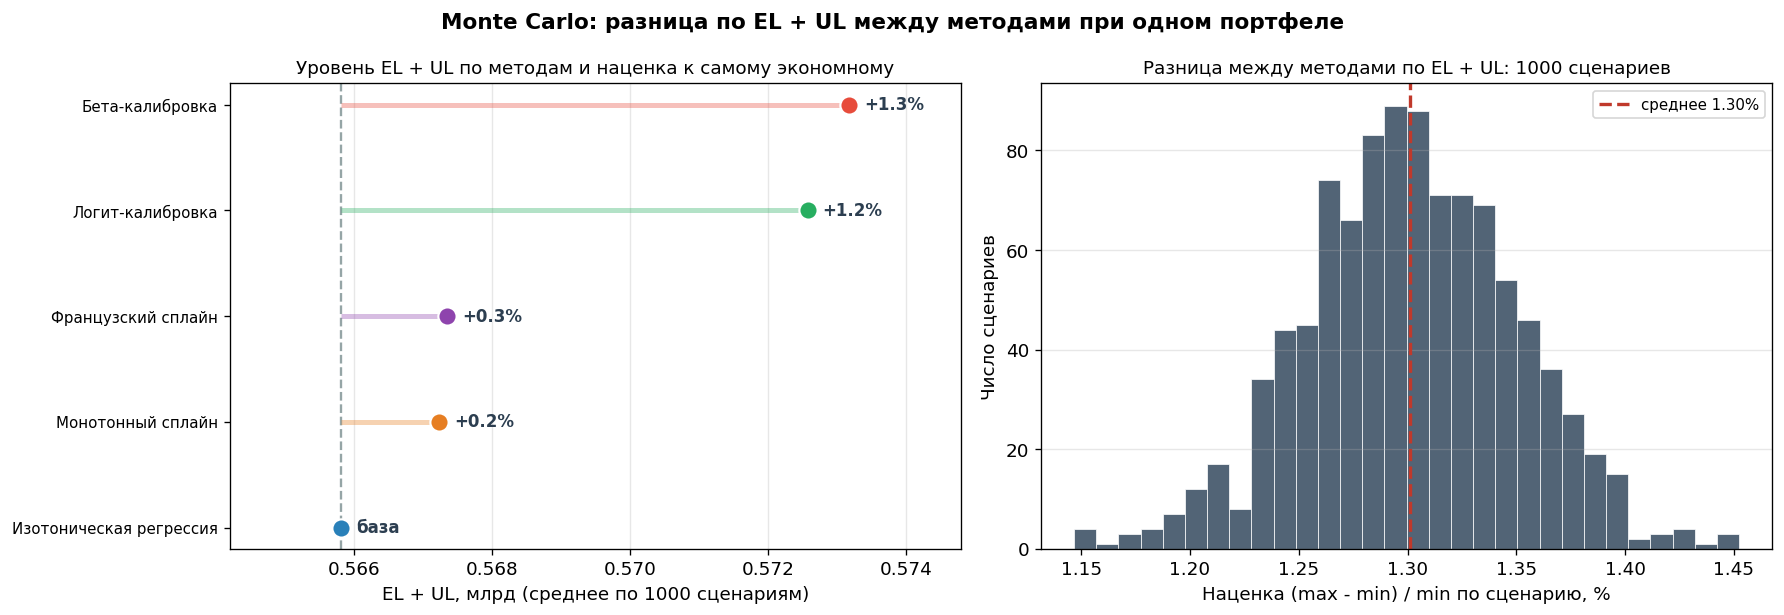

In [9]:
methods = list(summary["method"])
method_colors = {name: COLORS[i % len(COLORS)] for i, name in enumerate(methods)}

order = summary.sort_values("el_plus_ul_mean").reset_index(drop=True)
methods_sorted = order["method"].tolist()
levels_bln = order["el_plus_ul_mean"].to_numpy() / 1e9
cheapest = float(levels_bln.min())
markup = levels_bln / cheapest - 1.0

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

# --- Панель А: уровень EL+UL по методам, наценка к самому экономному ---
ax = axes[0]
y = np.arange(len(methods_sorted))
ax.axvline(cheapest, color="#95a5a6", ls="--", lw=1.4, zorder=1)
for i, (name, lv, mk) in enumerate(zip(methods_sorted, levels_bln, markup)):
    ax.hlines(i, cheapest, lv, color=method_colors[name], lw=3, alpha=0.35, zorder=2)
    ax.scatter(lv, i, color=method_colors[name], s=120, zorder=5, edgecolor="white", linewidth=1.3)
    label = "база" if mk <= 1e-9 else f"+{mk:.1%}"
    ax.annotate(label, (lv, i), xytext=(9, 0), textcoords="offset points",
                va="center", ha="left", fontsize=10, fontweight="bold", color="#2c3e50")
ax.set_yticks(y)
ax.set_yticklabels(methods_sorted, fontsize=9)
ax.set_xlabel("EL + UL, млрд (среднее по 1000 сценариям)")
ax.set_title("Уровень EL + UL по методам и наценка к самому экономному", fontsize=11)
ax.margins(x=0.22)
ax.grid(axis="x", alpha=0.3)

# --- Панель Б: распределение межметодной наценки по 1000 сценариям ---
ax = axes[1]
rel = spread["rel_diff"].to_numpy() * 100.0
ax.hist(rel, bins=30, color="#34495e", alpha=0.85, edgecolor="white", linewidth=0.5)
mean_rel = float(rel.mean())
ax.axvline(mean_rel, color="#c0392b", ls="--", lw=2.0, label=f"среднее {mean_rel:.2f}%")
ax.set_xlabel("Наценка (max - min) / min по сценарию, %")
ax.set_ylabel("Число сценариев")
ax.set_title(f"Разница между методами по EL + UL: {len(rel)} сценариев", fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.suptitle("Monte Carlo: разница по EL + UL между методами при одном портфеле", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Интерпретация

- **Средний PD на OOT и денежные метрики (EL / UL / EL+UL / RWA) устойчивы**: разброс max-min — доли процента от уровня метрики. Выводы раздела 8 основного ноутбука не зависят от того, какие именно ~80% портфеля попали в выборку.
- **Межметодный разброс EL + UL внутри сценария невелик** (разделы 3a, 4): самый консервативный и самый экономный метод различаются на единицы процентов; выбор калибратора не переворачивает капитальную картину.
- **Как целые модели все пять откалиброваны правильно.** Whole-model тест само-калибровки (суммарный факт дефолтов против суммы предсказанных PD) проходят все методы и на IN-TIME, и на OOT, практически на всех сценариях (раздел 3b). Это ожидаемо: модели приведены к ЦТ и корректно оценивают суммарный уровень риска.
- **По-грейдовый тест против фиксированной мастер-шкалы — только диагностика** (раздел 3b), и читать его без поправки на множественность нельзя: минимум по ~13 грейдам у идеальной модели уходит под 0.05 примерно в половине случаев. После поправки Холма на IN-TIME остаются ровно два адреса:
  - **грейд E — у всех пяти методов** (факт 0.470-0.472 против 0.400 по шкале). Раз флаг универсален, это не свойство метода: генератор кладёт в рейтинг E средний `true_pd` около 0.56 при заявленном в `PORTFOLIO_RATING_PD_BOUNDS` representative 0.40, и шкала ментора расходится с портфелем. Любая модель, честно наполняющая E, получит здесь флаг;
  - **грейд D2 — у логита и беты** (переоценка риска: шкала ждёт 10.3%, факт 6.9%).
  
  На OOT значимых отклонений нет ни у одного метода. Это не признак того, что на OOT модели лучше: в OOT один год вместо четырёх (8 776 наблюдений против 31 224), и у теста меньше мощности — то же отклонение в E даёт p=0.21 вместо 3.6e-10. На уровне модели целиком ничего из этого калибровку не ломает: суммарный PD и капитал у всех методов в норме.

**Про производительность.** бустинг-скоринг, по-строчный IRB-капитал и грейды мастер-шкалы предвычислены один раз в `prepare_fixed_pipeline`; сценарий только индексирует свою случайную ~80%-подвыборку и суммирует. 1000 ранов считаются за минуты.